In [90]:
import numpy as np
import matplotlib.pyplot as plt
steps = 150000
positions = np.zeros((steps, 3, 2))
velocities = np.zeros((steps, 3, 2))
TotEnergyErrors = np.zeros((steps,1))
h = 0.0003
G = 1.5

Mass1 = 10
Mass2 = 10
Mass3 = 10
r1i = np.array([ 12, -1.0])
r2i = np.array([ 0.0,  0.0])
r3i = np.array([-10,  1.0])
v1i = np.array([-0.1,  0.16666667])
v2i = np.array([-0.16666667, -0.63333333])
v3i = np.array([ 0.33333333,  0.46666667])
Eki = (0.5*Mass1*np.linalg.norm(v1i)**2)+(0.5*Mass2*np.linalg.norm(v2i)**2)+(0.5*Mass3*np.linalg.norm(v3i)**2)
Epi = -G*(((Mass1*Mass2)/np.linalg.norm(r2i - r1i))+((Mass1*Mass3)/np.linalg.norm(r3i - r1i))+((Mass2*Mass3)/np.linalg.norm(r3i - r2i)))
Etoti = Eki + Epi
print ("initial total energy = ", Etoti)
Ac1i = ((G*Mass2)*(r2i-r1i)/np.linalg.norm(r2i - r1i)**3)+((G*Mass3)*(r3i-r1i)/np.linalg.norm(r3i - r1i)**3)
Ac2i = ((G*Mass1)*(r1i-r2i)/np.linalg.norm(r1i - r2i)**3)+((G*Mass3)*(r3i-r2i)/np.linalg.norm(r3i - r2i)**3)
Ac3i = ((G*Mass1)*(r1i-r3i)/np.linalg.norm(r1i - r3i)**3)+((G*Mass2)*(r2i-r3i)/np.linalg.norm(r2i - r3i)**3)
i=0

for i in range(steps):
   # d12 = np.linalg.norm(r2i-r1i)
   # d13 = np.linalg.norm(r3i-r1i)
    #d23 = np.linalg.norm(r3i-r2i)
    #dmin = min(d12,d13,d23)
    #h = min(0.003, 0.001*dmin**(3))
    r1n = r1i + v1i*h+0.5*Ac1i*h**2
    r2n = r2i + v2i*h+0.5*Ac2i*h**2
    r3n = r3i + v3i*h+0.5*Ac3i*h**2
    Ac1n = ((G*Mass2)*(r2n-r1n)/np.linalg.norm(r2n - r1n)**3)+((G*Mass3)*(r3n-r1n)/np.linalg.norm(r3n - r1n)**3)
    Ac2n = ((G*Mass1)*(r1n-r2n)/np.linalg.norm(r1n - r2n)**3)+((G*Mass3)*(r3n-r2n)/np.linalg.norm(r3n - r2n)**3)
    Ac3n = ((G*Mass1)*(r1n-r3n)/np.linalg.norm(r1n - r3n)**3)+((G*Mass2)*(r2n-r3n)/np.linalg.norm(r2n - r3n)**3)
    v1n = v1i + 0.5*h*(Ac1i +Ac1n)
    v2n = v2i + 0.5*h*(Ac2i +Ac2n)
    v3n = v3i + 0.5*h*(Ac3i +Ac3n)
    r1i = r1n
    r2i = r2n
    r3i = r3n
    v1i = v1n
    v2i = v2n
    v3i = v3n
    Ac1i = Ac1n
    Ac2i =Ac2n
    Ac3i =Ac3n
    positions[i, 0] = r1n
    positions[i, 1] = r2n
    positions[i, 2] = r3n 
    velocities[i, 0] = v1n
    velocities[i, 1] = v2n
    velocities[i, 2] = v3n 
    TotEnergyErrors[i] = np.abs((Etoti - ((0.5*Mass1*np.linalg.norm(v1n)**2)+(0.5*Mass2*np.linalg.norm(v2n)**2)+(0.5*Mass3*np.linalg.norm(v3n)**2) -G*(((Mass1*Mass2)/np.linalg.norm(r2n - r1n))+((Mass1*Mass3)/np.linalg.norm(r3n - r1n))+((Mass2*Mass3)/np.linalg.norm(r3n - r2n)))))/Etoti)
    i= i+1 


initial total energy =  -30.1947830121775


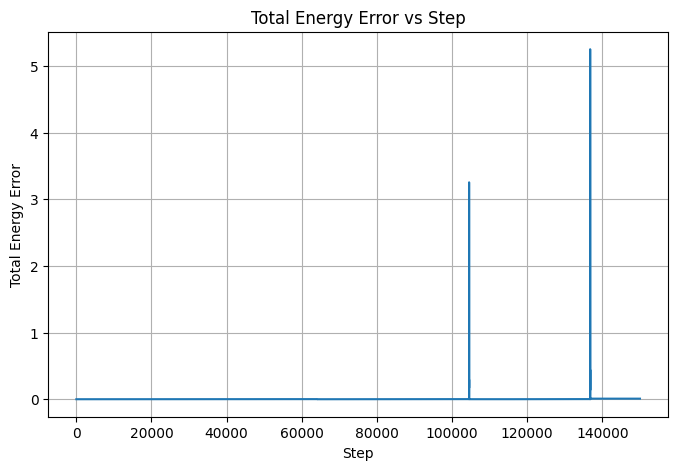

In [91]:
plt.figure(figsize=(8, 5))
plt.plot(range(steps), TotEnergyErrors.flatten())
plt.xlabel("Step")
plt.ylabel("Total Energy Error")
plt.title("Total Energy Error vs Step")
plt.grid(True)
plt.show()

In [ ]:
print("r1 =", r1n)
print("r2 =", r2n)
print("r3 =", r3n)
print("v1 =", v1n)
print("v2 =", v2n)
print("v3 =", v3n)

r1 = [-280.14511109  177.51050615]
r2 = [ 564.26011506 -340.93160629]
r3 = [-284.11510986  163.42120602]
v1 = [-0.06865302  0.31022212]
v2 = [-0.06531965  0.02425652]
v3 = [ 0.13397265 -0.33447862]


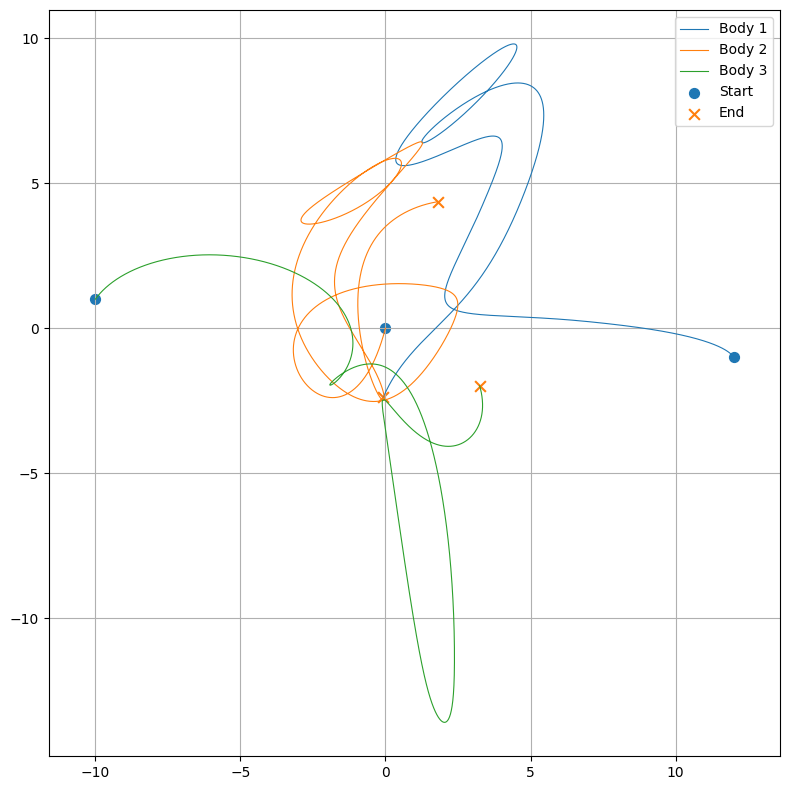

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

MAX_POINTS = 10000
stride = max(1, len(positions) // MAX_POINTS)

sample = positions[::stride]

plt.figure(figsize=(8, 8))

plt.plot(sample[:, 0, 0], sample[:, 0, 1], lw=0.8, label="Body 1")
plt.plot(sample[:, 1, 0], sample[:, 1, 1], lw=0.8, label="Body 2")
plt.plot(sample[:, 2, 0], sample[:, 2, 1], lw=0.8, label="Body 3")

plt.scatter(sample[0, :, 0], sample[0, :, 1],
            marker='o', s=50, label="Start")

plt.scatter(sample[-1, :, 0], sample[-1, :, 1],
            marker='x', s=60, label="End")

plt.axis("equal")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()